# Fourier Fingerprints 1D with Exponential Encoding

This notebook is self-contained and reproduces the 1D Fourier Fingerprint workflow using the existing Merlin circuit design. The input is renormalized on four optical modes with exponential factors `[1, 2, 4, 8]` before direct angle encoding.

The notebook does not import the project scripts.

## 1. Import Required Libraries

NumPy handles the grid and FFT operations, Matplotlib renders the signals and fingerprints, and Merlin provides the photonic quantum layer.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import merlin as ml
from merlin.builder import CircuitBuilder

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

EXPONENTIAL_FACTORS = [1.0, 2.0, 4.0, 8.0]
N_PHOTONS = 2
N_POINTS = 64
M_SAMPLES = 32

print("Exponential factors:", EXPONENTIAL_FACTORS)

Exponential factors: [1.0, 2.0, 4.0, 8.0]


## 2. Define Exponential Encoding Function

The classical input `x` is broadcast to four active optical modes and renormalized as `[x, 2x, 4x, 8x]`. The circuit then applies direct angle encoding to these four values.

In [3]:
def exponential_encode(x, factors=EXPONENTIAL_FACTORS):
    """Renormalize a batch of 1D inputs across exponentially scaled modes."""
    x = torch.as_tensor(x, dtype=torch.float32)
    if x.ndim == 1:
        x = x.unsqueeze(1)
    factor_tensor = torch.as_tensor(factors, dtype=torch.float32)
    return x * factor_tensor


class PhotonicSpectralModel(nn.Module):
    """Standalone 1D Merlin model using direct angle encoding."""

    def __init__(self, circuit_index=0, factors=EXPONENTIAL_FACTORS, n_photons=N_PHOTONS):
        super().__init__()
        self.factors = torch.tensor(factors, dtype=torch.float32)
        self.n_photons = n_photons
        self.n_active_modes = len(factors)
        self.n_modes = self.n_active_modes + 1
        self.measurement_strategy = ml.MeasurementStrategy.probs(
            computation_space=ml.ComputationSpace.FOCK
        )
        self.circuit_index = circuit_index
        self.n_encoding_layers = self._get_num_encoding_layers(circuit_index)
        self.quantum_layer = self._build_quantum_layer(circuit_index)

    @staticmethod
    def _get_num_encoding_layers(circuit_index):
        encoding_layers = {0: 1, 1: 1, 2: 2, 3: 1}
        if circuit_index not in encoding_layers:
            raise ValueError(f"Unknown circuit index: {circuit_index}")
        return encoding_layers[circuit_index]

    def _add_encoding(self, builder):
        builder.add_angle_encoding(
            modes=list(range(self.n_active_modes)),
            name="data_encoding",
        )

    def _build_circuit(self, circuit_index):
        builder = CircuitBuilder(n_modes=self.n_modes)
        if circuit_index == 0:
            builder.add_entangling_layer(trainable=True, model="mzi", name="init_mzi")
            self._add_encoding(builder)
            builder.add_entangling_layer(trainable=True, model="mzi", name="mid_mzi")
        elif circuit_index == 1:
            for index, targets in enumerate(((0, 1), (3, 4), (2, 3), (1, 2), (3, 4), (0, 1))):
                builder.add_superpositions(
                    targets=targets,
                    trainable_theta=True,
                    name=f"bs{index + 1}",
                )
            self._add_encoding(builder)
            for index, targets in enumerate(((0, 1), (3, 4), (2, 3), (1, 2), (3, 4), (0, 1)), start=11):
                builder.add_superpositions(
                    targets=targets,
                    trainable_theta=True,
                    name=f"bs{index}",
                )
        elif circuit_index == 2:
            builder.add_entangling_layer(trainable=True, model="mzi", name="pre_mzi_0")
            self._add_encoding(builder)
            builder.add_entangling_layer(trainable=True, model="mzi", name="pre_mzi_1")
            self._add_encoding(builder)
            builder.add_entangling_layer(trainable=True, model="mzi", name="post_mzi")
        elif circuit_index == 3:
            for index, targets in enumerate(((0, 1), (1, 2), (2, 3), (3, 4))):
                builder.add_superpositions(
                    targets=targets,
                    trainable_theta=True,
                    name=f"bs{index + 1}",
                )
            self._add_encoding(builder)
            for index, targets in enumerate(((3, 4), (2, 3), (1, 2), (0, 1)), start=1):
                builder.add_superpositions(
                    targets=targets,
                    trainable_theta=True,
                    name=f"post_bs{index}",
                )
        else:
            raise ValueError(f"Unknown circuit index: {circuit_index}")
        return builder

    def _build_quantum_layer(self, circuit_index):
        return ml.QuantumLayer(
            input_size=self.n_active_modes * self.n_encoding_layers,
            builder=self._build_circuit(circuit_index),
            n_photons=self.n_photons,
            measurement_strategy=self.measurement_strategy,
            dtype=torch.float32,
        )

    def forward(self, x):
        encoded_input = exponential_encode(x, self.factors)
        repeated_input = torch.cat([encoded_input] * self.n_encoding_layers, dim=1)
        return self.quantum_layer(repeated_input)


example_input = torch.tensor([[0.25], [1.0]])
print(exponential_encode(example_input))

tensor([[0.2500, 0.5000, 1.0000, 2.0000],
        [1.0000, 2.0000, 4.0000, 8.0000]])


## 3. Compute Fourier Fingerprints

For each random circuit parameter configuration, the notebook evaluates the probability that the first optical mode contains at least one photon. The real FFT of this signal gives the Fourier fingerprint.

In [4]:
def compute_fourier_fingerprint(model, M=M_SAMPLES, n_points=N_POINTS):
    """Sample circuit parameters and compute the covariance-style fingerprint."""
    x_grid = torch.from_numpy(
        np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    ).float().unsqueeze(1)
    coefficients = []

    for sample_index in range(M):
        with torch.no_grad():
            for parameter in model.parameters():
                if parameter.requires_grad:
                    parameter.data.uniform_(0, 2 * np.pi)

            probabilities = model(x_grid)
            signal = probabilities[:, :5].sum(dim=1).numpy()

        coefficients.append(np.abs(np.fft.rfft(signal) / n_points))

    coefficient_matrix = np.asarray(coefficients)
    variances = np.var(coefficient_matrix, axis=0)
    active_indices = np.where(variances > 1e-8)[0]
    active_coefficients = coefficient_matrix[:, active_indices]

    n_active = len(active_indices)
    if n_active == 0:
        fingerprint = np.empty((0, 0))
        fcc = 0.0
    elif n_active == 1:
        fingerprint = np.ones((1, 1))
        fcc = 0.0
    else:
        fingerprint = np.atleast_2d(
            np.nan_to_num(
                np.corrcoef(active_coefficients, rowvar=False),
                nan=0.0,
            )
        )
        off_diagonal = ~np.eye(n_active, dtype=bool)
        fcc = float(np.mean(np.abs(fingerprint[off_diagonal])))

    return {
        "fingerprint": fingerprint,
        "fcc": fcc,
        "frequencies": active_indices,
        "coefficients": active_coefficients,
        "grid": x_grid.squeeze(1).numpy(),
    }


models = {f"circuit_{index}": PhotonicSpectralModel(circuit_index=index) for index in range(4)}
results = {
    name: compute_fourier_fingerprint(model)
    for name, model in models.items()
}

for name, result in results.items():
    print(f"{name}: {len(result['frequencies'])} active frequencies, FCC = {result['fcc']:.5f}")

circuit_0: 17 active frequencies, FCC = 0.20855
circuit_1: 12 active frequencies, FCC = 0.21773
circuit_2: 30 active frequencies, FCC = 0.27596
circuit_3: 15 active frequencies, FCC = 0.23488


## 4. Visualize Input Signal and Encoding

The plot below compares a scalar 1D input signal with the four exponentially rescaled signals sent to the optical modes.

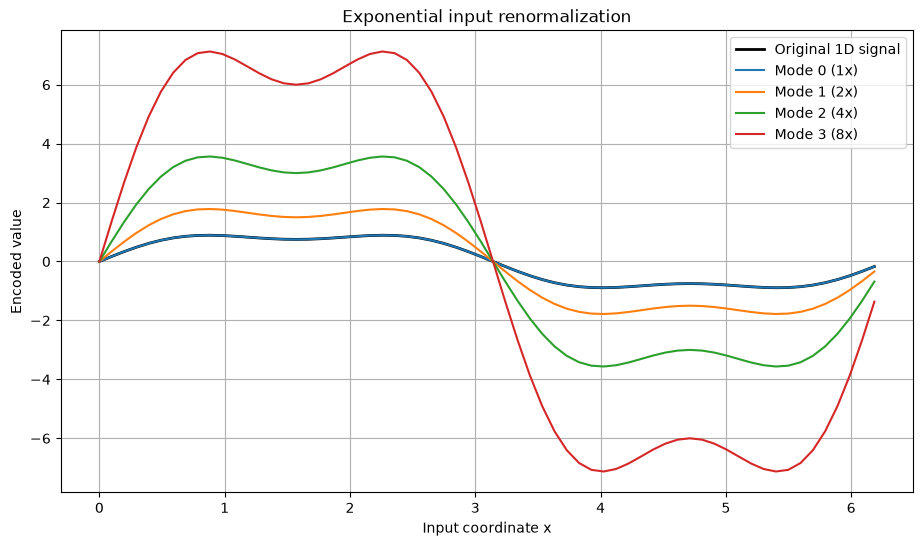

In [5]:
x = np.linspace(0, 2 * np.pi, N_POINTS, endpoint=False)
input_signal = np.sin(x) + 0.25 * np.sin(3 * x)
encoded_signal = exponential_encode(torch.from_numpy(input_signal).float()).numpy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, input_signal, color="black", linewidth=2, label="Original 1D signal")
for mode_index, factor in enumerate(EXPONENTIAL_FACTORS):
    ax.plot(
        x,
        encoded_signal[:, mode_index],
        label=f"Mode {mode_index} ({factor:g}x)",
    )
ax.set_title("Exponential input renormalization")
ax.set_xlabel("Input coordinate x")
ax.set_ylabel("Encoded value")
ax.legend()
plt.show()

## 5. Visualize Fourier Fingerprint Results

The fingerprint uses magnitude correlations across random parameter configurations. For one representative circuit evaluation, the plots also show the FFT magnitude and phase.

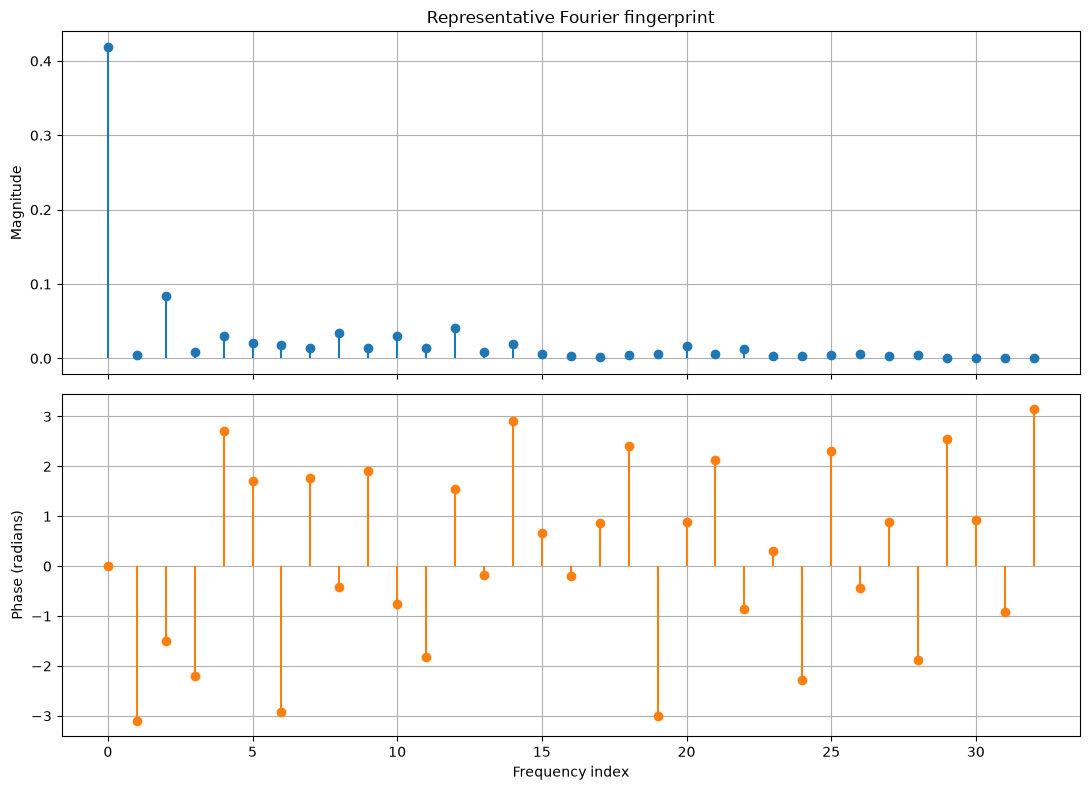

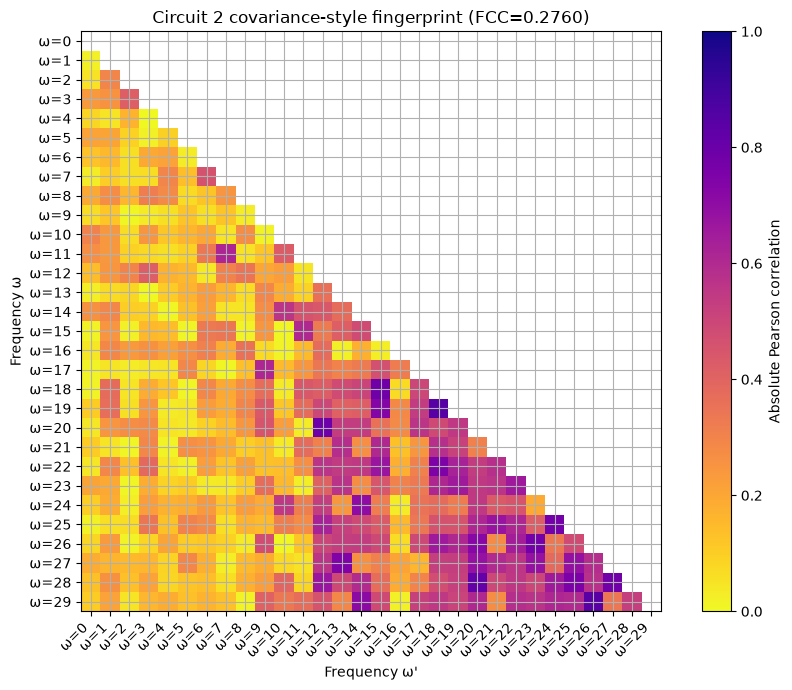

In [6]:
representative_model = PhotonicSpectralModel(circuit_index=2)
with torch.no_grad():
    for parameter in representative_model.parameters():
        if parameter.requires_grad:
            parameter.data.uniform_(0, 2 * np.pi)
    representative_probabilities = representative_model(
        torch.from_numpy(x).float().unsqueeze(1)
    )
representative_signal = representative_probabilities[:, :5].sum(dim=1).numpy()
representative_fft = np.fft.rfft(representative_signal) / N_POINTS
representative_frequencies = np.fft.rfftfreq(N_POINTS, d=1.0 / N_POINTS)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].stem(
    representative_frequencies,
    np.abs(representative_fft),
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" ",
)
axes[0].set_ylabel("Magnitude")
axes[0].set_title("Representative Fourier fingerprint")
axes[1].stem(
    representative_frequencies,
    np.angle(representative_fft),
    linefmt="C1-",
    markerfmt="C1o",
    basefmt=" ",
)
axes[1].set_xlabel("Frequency index")
axes[1].set_ylabel("Phase (radians)")
plt.tight_layout()
plt.show()

fingerprint = results["circuit_2"]["fingerprint"]
fingerprint_frequencies = results["circuit_2"]["frequencies"]
if fingerprint.size:
    mask = np.triu(np.ones_like(fingerprint, dtype=bool))
    displayed_fingerprint = np.ma.masked_array(np.abs(fingerprint), mask)
    fig, ax = plt.subplots(figsize=(9, 7))
    image = ax.imshow(displayed_fingerprint, cmap="plasma_r", vmin=0, vmax=1)
    labels = [f"ω={frequency}" for frequency in fingerprint_frequencies]
    ax.set_xticks(range(len(labels)), labels=labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)), labels=labels)
    ax.set_title(f"Circuit 2 covariance-style fingerprint (FCC={results['circuit_2']['fcc']:.4f})")
    ax.set_xlabel("Frequency ω'")
    ax.set_ylabel("Frequency ω")
    fig.colorbar(image, ax=ax, label="Absolute Pearson correlation")
    plt.tight_layout()
    plt.show()

## 6. Compare Multiple Signals

Different input signals are passed through the same exponential encoding and the same representative circuit. Their resulting Fourier fingerprints can be compared by their magnitude spectra.

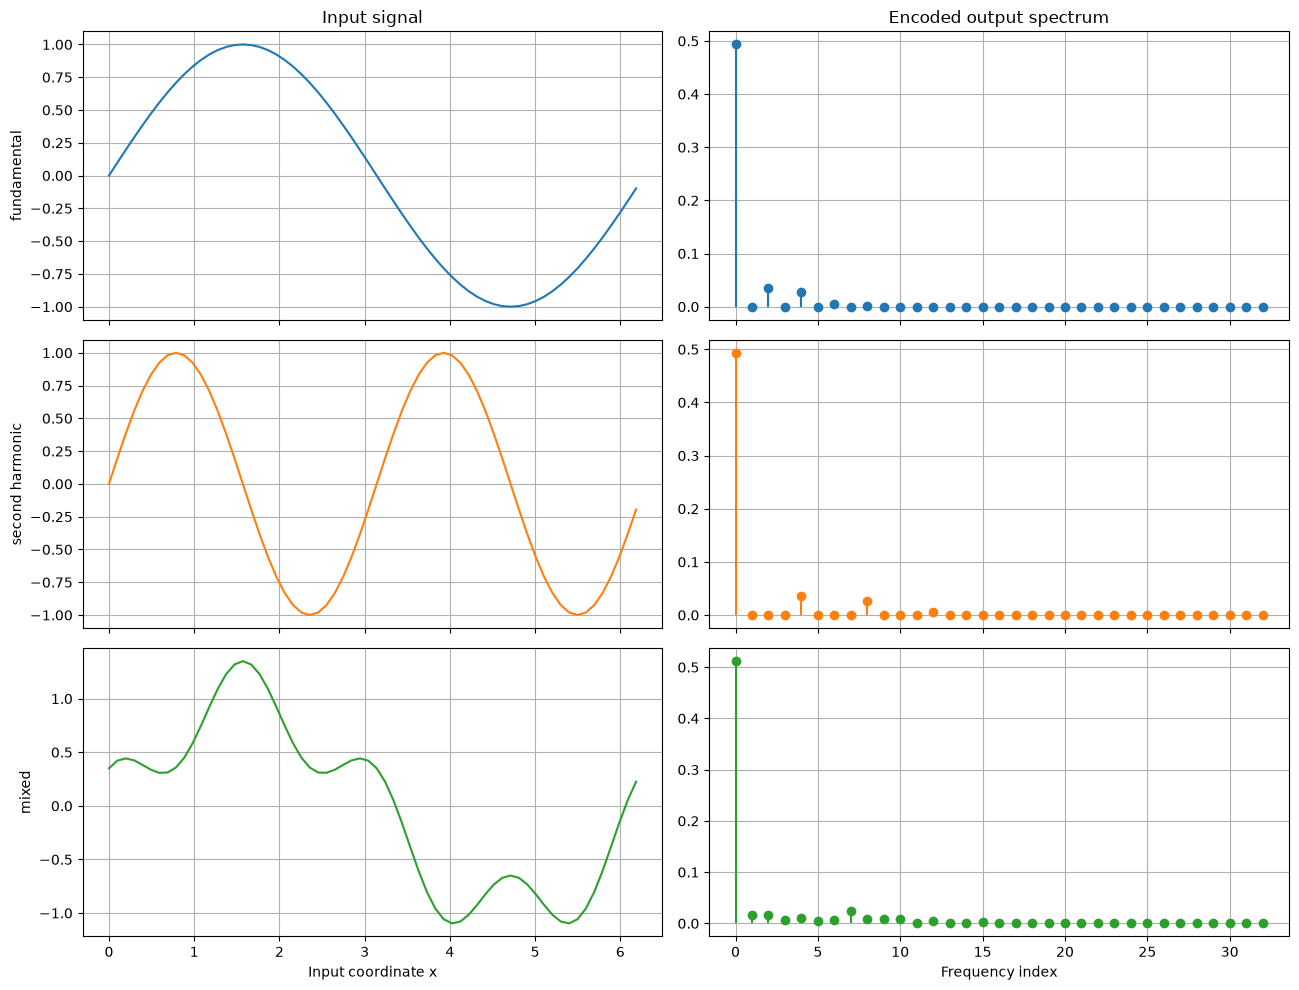

In [7]:
signals = {
    "fundamental": np.sin(x),
    "second harmonic": np.sin(2 * x),
    "mixed": np.sin(x) + 0.35 * np.cos(4 * x),
}

comparison_model = PhotonicSpectralModel(circuit_index=1)
with torch.no_grad():
    for parameter in comparison_model.parameters():
        if parameter.requires_grad:
            parameter.data.uniform_(0, 2 * np.pi)

fig, axes = plt.subplots(len(signals), 2, figsize=(13, 10), sharex="col")
for row, (signal_name, signal_values) in enumerate(signals.items()):
    model_signal = comparison_model(
        torch.from_numpy(signal_values).float().unsqueeze(1)
    )[:, :5].sum(dim=1).detach().numpy()
    spectrum = np.fft.rfft(model_signal) / N_POINTS

    axes[row, 0].plot(x, signal_values, color=f"C{row}")
    axes[row, 0].set_ylabel(signal_name)
    axes[row, 0].set_title("Input signal" if row == 0 else "")

    axes[row, 1].stem(
        np.fft.rfftfreq(N_POINTS, d=1.0 / N_POINTS),
        np.abs(spectrum),
        linefmt=f"C{row}-",
        markerfmt=f"C{row}o",
        basefmt=" ",
    )
    axes[row, 1].set_title("Encoded output spectrum" if row == 0 else "")

axes[-1, 0].set_xlabel("Input coordinate x")
axes[-1, 1].set_xlabel("Frequency index")
plt.tight_layout()
plt.show()